In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torchmetrics import Accuracy, F1Score, AUROC, Precision, Recall
from HistoLib import pytorch_dataset, pytorch_model, pytorch_gradcam, utils


2026-03-04 10:12:29.834863: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
utils.dataset_description()

Total images 691
Total patients 45


,20x,40x,Total
aca_bd,57,46,103
aca_md,44,46,90
aca_pd,45,42,87
nor,85,66,151
scc_bd,50,49,99
scc_md,30,36,66
scc_pd,48,47,95
Total,359,332,691


## Get images

In [3]:
resolution = '20x'      # One of ['20x', '40x']

train_loader, val_loader, test_loader, class_names = pytorch_dataset.get_dataloaders(
    resolution=resolution,
    batch_size=8,
    image_scale=0.25, # Consistent with baseline
    reproducible=True # Use the splits from the original paper.
)
print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

def show_batch(loader, title="Batch"):
    images, labels = next(iter(loader))
    plt.figure(figsize=(15, 6))
    for i in range(min(8, len(images))):
        plt.subplot(2, 4, i + 1)
        # Denormalize
        img = images[i].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"Class: {class_names[labels[i].item()]}")
        plt.axis('off')
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()


Number of training batches: 33
Number of validation batches: 6
Number of test batches: 6


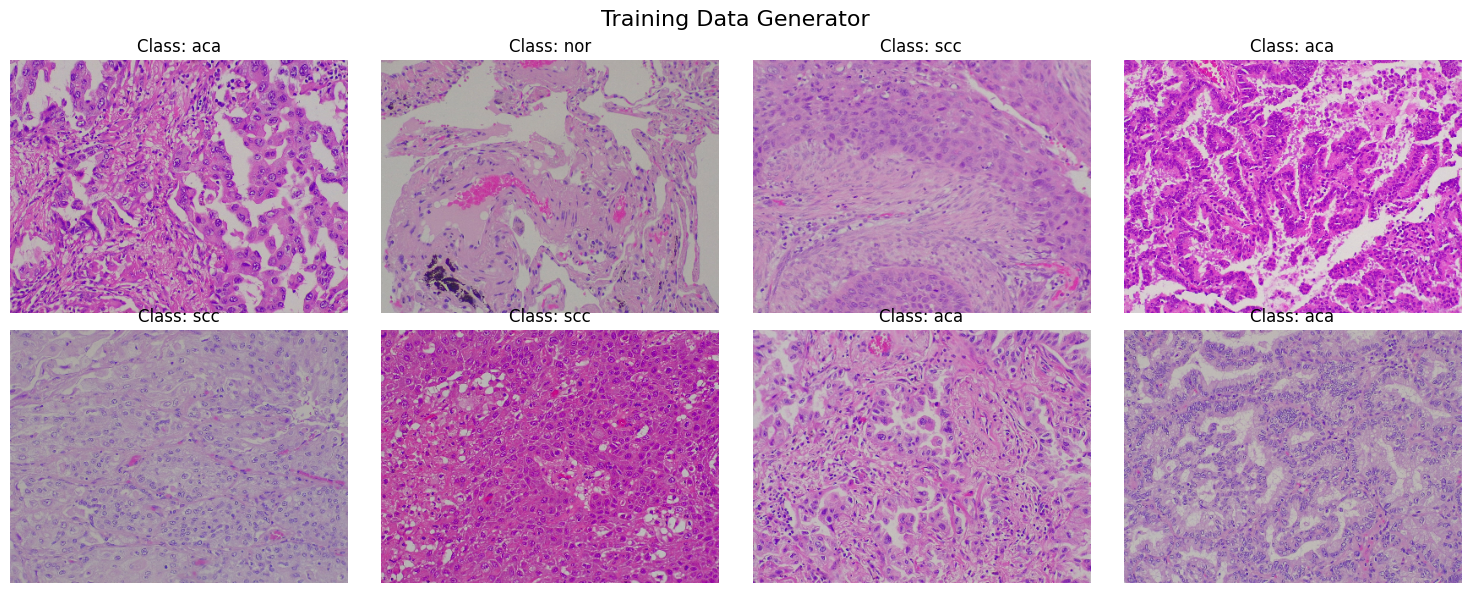

In [4]:
show_batch(train_loader, "Training Data Generator")


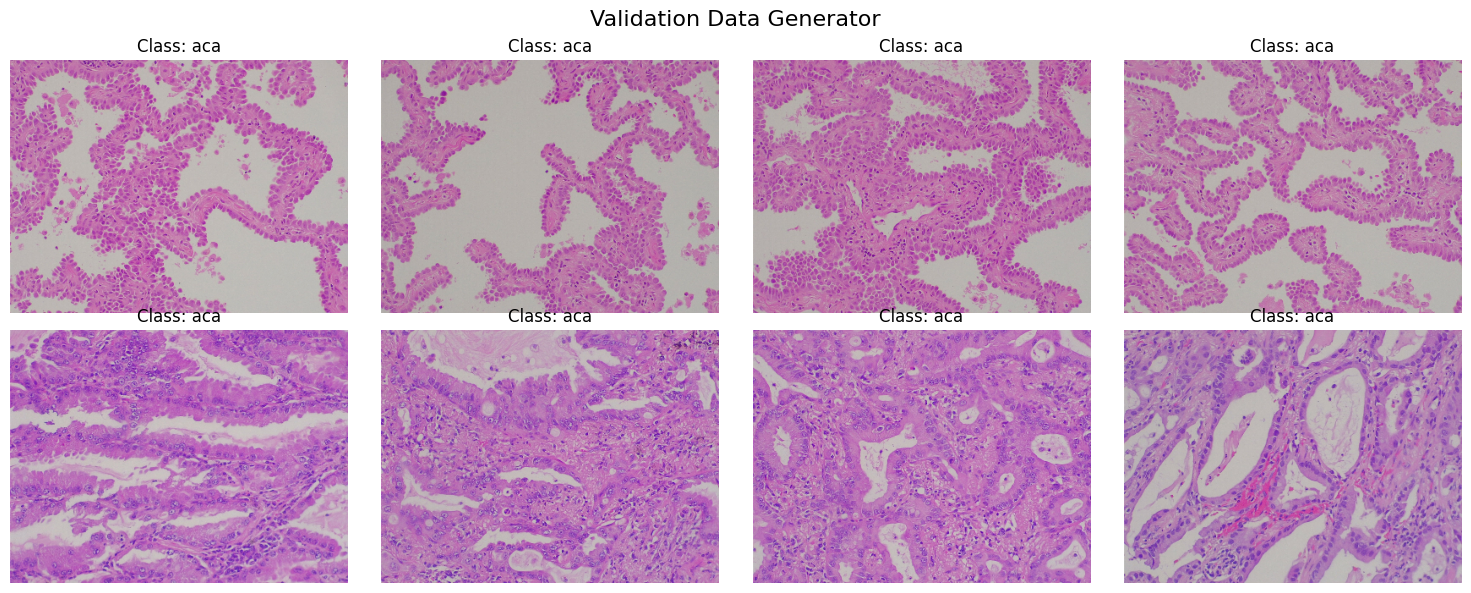

In [5]:
show_batch(val_loader, "Validation Data Generator")


## Train Model

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
num_classes = len(class_names)
model = pytorch_model.get_model(num_classes).to(device)


Using device: cuda


In [7]:
# Compute class weights
train_labels = train_loader.dataset.labels
class_counts = np.bincount(train_labels)
total_samples = len(train_labels)
weights = total_samples / (num_classes * class_counts)
weights_tensor = torch.tensor(weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1)

metrics_collection = {
    'acc': Accuracy(task="multiclass", num_classes=num_classes).to(device),
    'f1': F1Score(task="multiclass", num_classes=num_classes, average='macro').to(device),
    'auc': AUROC(task="multiclass", num_classes=num_classes).to(device),
    'precision': Precision(task="multiclass", num_classes=num_classes, average='macro').to(device),
    'recall': Recall(task="multiclass", num_classes=num_classes, average='macro').to(device)
}

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_auc': [], 'val_auc': []}

epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for m in metrics_collection.values(): m.reset()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        for m in metrics_collection.values(): m(outputs, labels)
        pbar.set_postfix({'loss': loss.item()})
        
    train_loss = running_loss / len(train_loader)
    train_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}
    
    model.eval()
    val_running_loss = 0.0
    for m in metrics_collection.values(): m.reset()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            for m in metrics_collection.values(): m(outputs, labels)
            
    val_loss = val_running_loss / len(val_loader)
    val_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}
    scheduler.step(val_loss)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_metrics['acc'])
    history['val_acc'].append(val_metrics['acc'])
    history['train_auc'].append(train_metrics['auc'])
    history['val_auc'].append(val_metrics['auc'])
    
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Acc: {train_metrics['acc']:.4f} - Val Loss: {val_loss:.4f}, Acc: {val_metrics['acc']:.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'baseline_pytorch_best.pth')


Epoch 1/10 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/10 - Train Loss: 1.0675, Acc: 0.4221 - Val Loss: 0.9912, Acc: 0.5208


Epoch 2/10 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 2/10 - Train Loss: 0.8930, Acc: 0.6426 - Val Loss: 0.7678, Acc: 0.7292


Epoch 3/10 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

...

Epoch 8/10 - Train Loss: 0.2385, Acc: 0.9202 - Val Loss: 0.3091, Acc: 0.8750


Epoch 9/10 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 9/10 - Train Loss: 0.1951, Acc: 0.9163 - Val Loss: 0.4835, Acc: 0.8542


Epoch 10/10 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 10/10 - Train Loss: 0.2162, Acc: 0.9240 - Val Loss: 0.4126, Acc: 0.8542


## Evaluate using test data

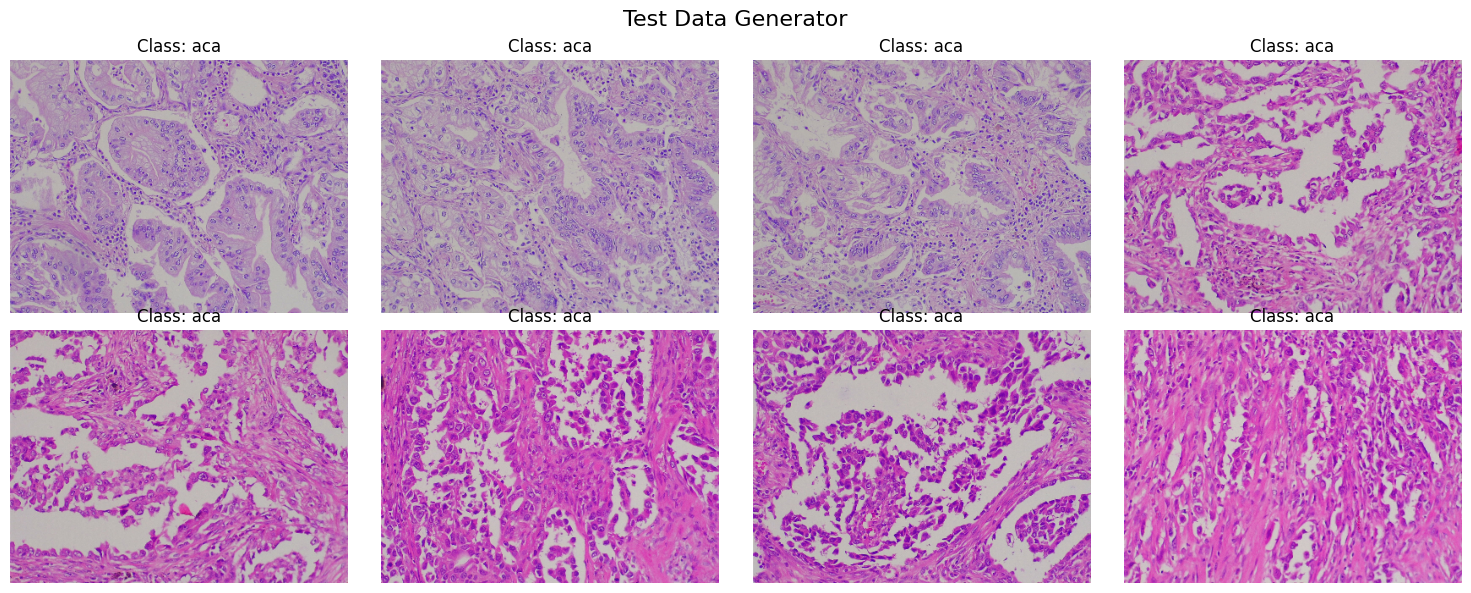

In [8]:
show_batch(test_loader, "Test Data Generator")


Test Loss: 0.2506
Test Accuracy: 0.9167
Test F1 Score: 0.9083


Evaluation metrics saved to 'evaluation_metrics.png'


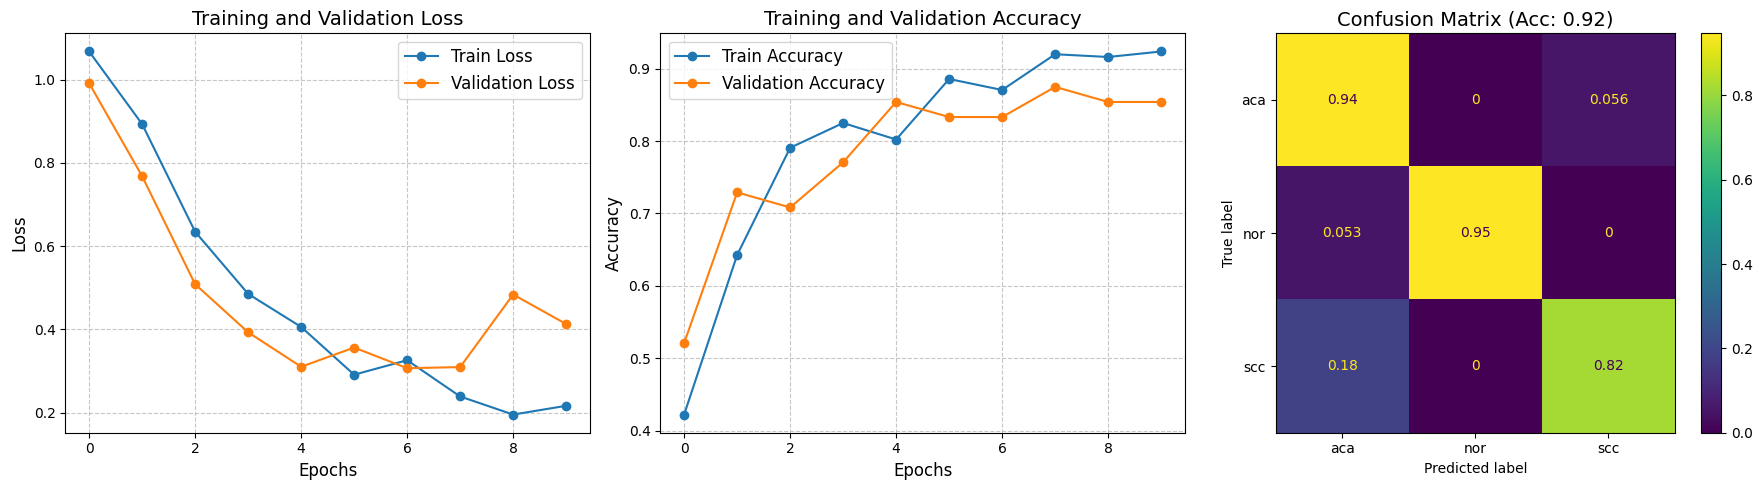

In [9]:
model.load_state_dict(torch.load('baseline_pytorch_best.pth'))
model.eval()
test_loss = 0.0
for m in metrics_collection.values(): m.reset()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        for m in metrics_collection.values(): m(outputs, labels)
        
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)
test_metrics = {name: m.compute().item() for name, m in metrics_collection.items()}

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_metrics['acc']:.4f}")
print(f"Test F1 Score: {test_metrics['f1']:.4f}")


from sklearn.metrics import ConfusionMatrixDisplay
import numpy as np

# Plot and save nicely formatted metrics
fig, axs = plt.subplots(1, 4, figsize=(24, 5))

# Plot Loss
axs[0].plot(history['train_loss'], label='Train Loss', marker='o')
axs[0].plot(history['val_loss'], label='Validation Loss', marker='o')
axs[0].set_title('Training and Validation Loss', fontsize=14)
axs[0].set_xlabel('Epochs', fontsize=12)
axs[0].set_ylabel('Loss', fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.7)
axs[0].legend(fontsize=12)

# Plot Accuracy
axs[1].plot(history['train_acc'], label='Train Accuracy', marker='o')
axs[1].plot(history['val_acc'], label='Validation Accuracy', marker='o')
axs[1].set_title('Training and Validation Accuracy', fontsize=14)
axs[1].set_xlabel('Epochs', fontsize=12)
axs[1].set_ylabel('Accuracy', fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.7)
axs[1].legend(fontsize=12)

# Plot AUC
axs[2].plot(history['train_auc'], label='Train AUC', marker='o')
axs[2].plot(history['val_auc'], label='Validation AUC', marker='o')
axs[2].set_title('Training and Validation AUC', fontsize=14)
axs[2].set_xlabel('Epochs', fontsize=12)
axs[2].set_ylabel('AUC', fontsize=12)
axs[2].grid(True, linestyle='--', alpha=0.7)
axs[2].legend(fontsize=12)

# Plot Confusion Matrix
ConfusionMatrixDisplay.from_predictions(all_labels, all_preds, display_labels=class_names, normalize='true', values_format='.2%', ax=axs[3])
axs[3].set_title(f"Confusion Matrix (Accuracy)", fontsize=14)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=300, bbox_inches='tight')
print("Evaluation metrics saved to 'evaluation_metrics.png'")
plt.show()


Generating Grad-CAM samples...


Grad-CAM samples saved to gradcam_samples.png
Grad-CAM samples saved to 'gradcam_samples.png'


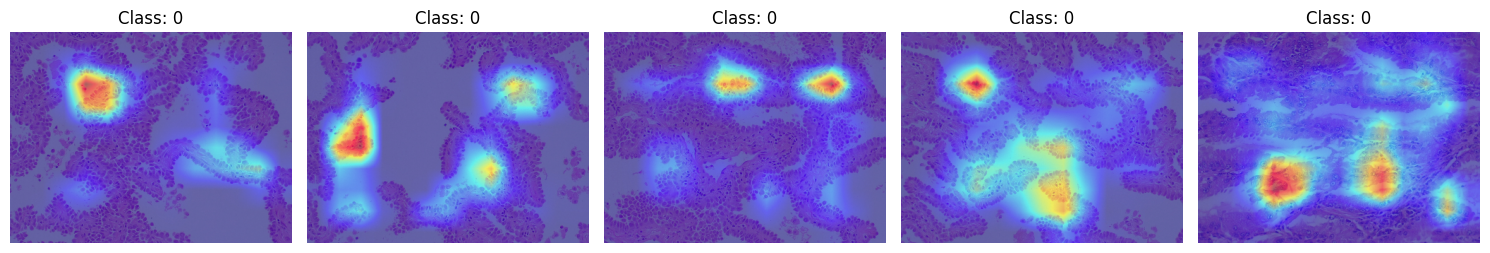

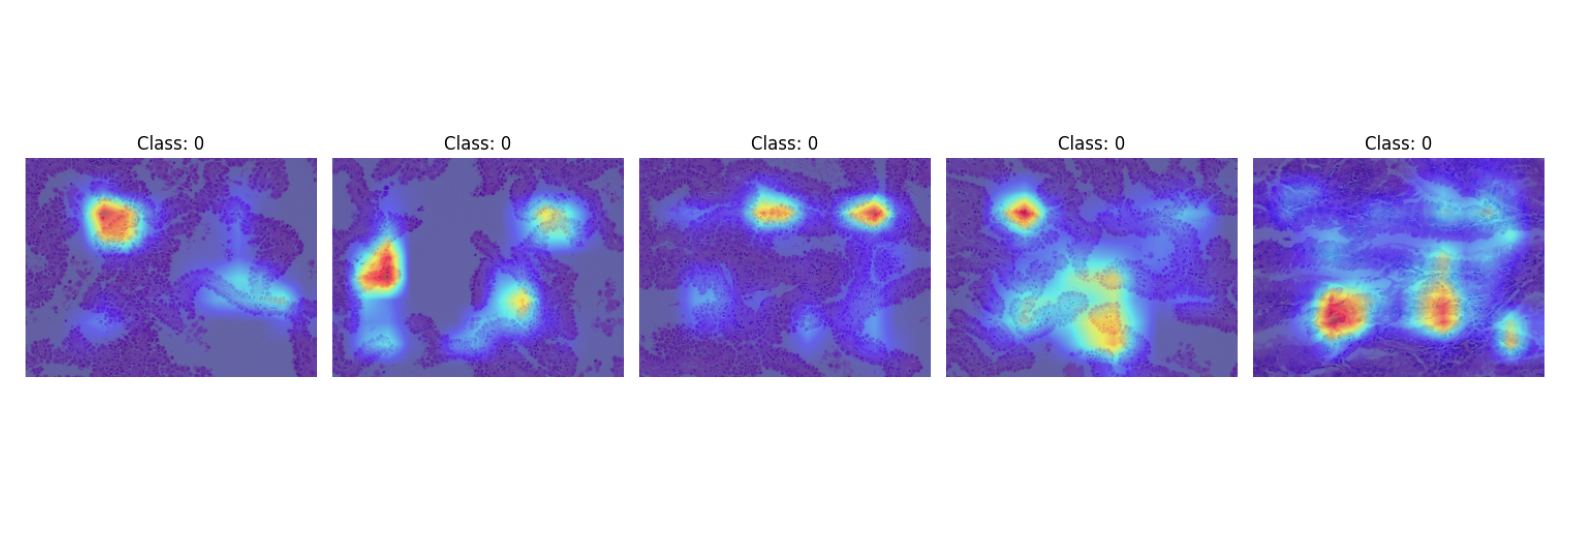

In [10]:
print("Generating Grad-CAM samples...")
model.eval()
pytorch_gradcam.generate_samples(
    model, 
    val_loader, 
    device, 
    num_samples=5, 
    output_path='gradcam_samples.png'
)
print("Grad-CAM samples saved to 'gradcam_samples.png'")
import matplotlib.image as mpimg
img = mpimg.imread('gradcam_samples.png')
plt.figure(figsize=(20, 10))
plt.imshow(img)
plt.axis('off')
plt.show()
